# HydroGraph Project Part 1 : Data

## 1. Loading Data

In [2]:
import requests

url = "https://maps.ottawa.ca/arcgis/rest/services/WaterandWastewaterInfrastructure/MapServer/8/query"

pipes = []

offset = 0
batch_size = 1000

while True:
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "resultOffset": offset,
        "resultRecordCount": batch_size,
        "f": "json"
    }

    data = requests.get(url, params=params).json()

    features = data.get("features", [])

    if len(features) == 0:
        break

    pipes.extend(features)


    offset += batch_size
pipes

[{'attributes': {'OBJECTID': 3,
   'SUBTYPE': 1,
   'STRUCT_ID': 'SAN10007',
   'STRUCT_TYPE': 'SANP',
   'OWNERSHIP': 'PUBLIC',
   'INSTALL_YEAR': 1992,
   'WIDTH': 250,
   'MATERIAL': 'PVC',
   'INVERT_UPSTREAM': 112.4800033569336,
   'INVERT_DOWNSTREAM': 111.45999908447266,
   'FUNCTION': None,
   'LIFE_CYCLE_STATUS': 'IN_SERVICE',
   'SHAPE_Length': 88.8275959939448,
   'ENABLED': 1,
   'GLOBALID': '{42FA8C85-5F59-45AA-873B-7552758F582D}',
   'LENGTHASBUILT': 62.7},
  'geometry': {'paths': [[[-8463015.0737, 5676545.834600002],
     [-8462955.2619, 5676480.1620000005]]]}},
 {'attributes': {'OBJECTID': 4,
   'SUBTYPE': 1,
   'STRUCT_ID': 'SAN12058',
   'STRUCT_TYPE': 'SANP',
   'OWNERSHIP': 'PUBLIC',
   'INSTALL_YEAR': 1990,
   'WIDTH': 300,
   'MATERIAL': 'PVC',
   'INVERT_UPSTREAM': 95.7300033569336,
   'INVERT_DOWNSTREAM': 95.6500015258789,
   'FUNCTION': None,
   'LIFE_CYCLE_STATUS': 'IN_SERVICE',
   'SHAPE_Length': 37.238052588438,
   'ENABLED': 1,
   'GLOBALID': '{3A14750B-4AFF

In [3]:
import pandas as pd
pipes_a = pd.DataFrame([object["attributes"] for object in pipes])
pipes_gx1 = pd.DataFrame([object["geometry"]["paths"][0][0][0] for object in pipes], columns=["x1"])
pipes_gy1 = pd.DataFrame([object["geometry"]["paths"][0][0][1] for object in pipes], columns=["y1"])
pipes_gx2 = pd.DataFrame([object["geometry"]["paths"][0][1][0] for object in pipes], columns=["x2"])
pipes_gy2 = pd.DataFrame([object["geometry"]["paths"][0][1][1] for object in pipes], columns=["y2"])

In [4]:
pipes = pd.concat([pipes_a, pipes_gx1, pipes_gy1, pipes_gx2, pipes_gy2], axis=1)
pipes.head()

,OBJECTID,SUBTYPE,STRUCT_ID,STRUCT_TYPE,OWNERSHIP,INSTALL_YEAR,WIDTH,MATERIAL,INVERT_UPSTREAM,INVERT_DOWNSTREAM,FUNCTION,LIFE_CYCLE_STATUS,SHAPE_Length,ENABLED,GLOBALID,LENGTHASBUILT,x1,y1,x2,y2
0,3,1,SAN10007,SANP,PUBLIC,1992.0,250.0,PVC,112.480003,111.459999,NaN,IN_SERVICE,88.827596,1,{42FA8C85-5F59-45AA-873B-7552758F582D},62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06
1,4,1,SAN12058,SANP,PUBLIC,1990.0,300.0,PVC,95.730003,95.650002,NaN,IN_SERVICE,37.238053,1,{3A14750B-4AFF-4E5E-B75B-3C2E804D45AF},26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06
2,5,1,SAN21525,SANP,PUBLIC,1986.0,250.0,PVC,82.421997,82.335999,NaN,IN_SERVICE,30.847637,1,{B085289C-887E-4632-AE88-E409CEA479A8},20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06
3,6,1,SAN21574,SANP,PUBLIC,1985.0,250.0,PVC,82.658997,82.358002,NaN,IN_SERVICE,125.410753,1,{A5769DE4-F6FB-452B-9B80-DE00D308B704},88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06
4,7,1,SAN00464,SANP,PUBLIC,1983.0,900.0,CONC,64.730003,63.803001,COLLECTOR,IN_SERVICE,120.911625,1,{33EAE45F-3C82-4090-8200-22AA29B195D7},85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06


## 2. Data Preprocessing

In [5]:
pipes.info()

<class 'pandas.DataFrame'>
RangeIndex: 61311 entries, 0 to 61310
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           61311 non-null  int64  
 1   SUBTYPE            61311 non-null  int64  
 2   STRUCT_ID          61311 non-null  str    
 3   STRUCT_TYPE        61311 non-null  str    
 4   OWNERSHIP          61311 non-null  str    
 5   INSTALL_YEAR       61229 non-null  float64
 6   WIDTH              61257 non-null  float64
 7   MATERIAL           61306 non-null  str    
 8   INVERT_UPSTREAM    61220 non-null  float64
 9   INVERT_DOWNSTREAM  61233 non-null  float64
 10  FUNCTION           35436 non-null  str    
 11  LIFE_CYCLE_STATUS  61311 non-null  str    
 12  SHAPE_Length       61311 non-null  float64
 13  ENABLED            61311 non-null  int64  
 14  GLOBALID           61311 non-null  str    
 15  LENGTHASBUILT      60254 non-null  float64
 16  x1                 61311 non-null

In [6]:
pipes.describe()

,OBJECTID,SUBTYPE,INSTALL_YEAR,WIDTH,INVERT_UPSTREAM,INVERT_DOWNSTREAM,SHAPE_Length,ENABLED,LENGTHASBUILT,x1,y1,x2,y2
count,6.131100e+04,61311.0,61229.000000,61257.000000,61220.000000,61233.000000,61311.000000,61311.000000,60254.000000,6.131100e+04,6.131100e+04,6.131100e+04,6.131100e+04
mean,1.761945e+05,1.0,1858.956295,290.801704,76.463663,75.918374,81.266695,0.999984,59.887972,-8.428249e+06,5.678177e+06,-8.428248e+06,5.678186e+06
std,2.562907e+05,0.0,499.085108,196.987834,26.991386,27.121519,90.885032,0.004039,112.832307,1.458791e+04,1.150799e+04,1.458216e+04,1.150672e+04
min,3.000000e+00,1.0,0.000000,-2.000000,0.000000,0.000000,0.338171,0.000000,0.000000,-8.484344e+06,5.644523e+06,-8.484348e+06,5.644955e+06
25%,3.429250e+04,1.0,1972.000000,200.000000,67.093752,66.459999,37.881352,1.000000,27.000000,-8.436864e+06,5.667890e+06,-8.436851e+06,5.667887e+06
50%,6.826300e+04,1.0,1992.000000,250.000000,83.800003,83.488998,77.456605,1.000000,55.000000,-8.427938e+06,5.677906e+06,-8.427922e+06,5.677923e+06
75%,1.190670e+05,1.0,2010.000000,250.000000,91.769997,91.403000,112.539821,1.000000,79.300000,-8.419149e+06,5.688410e+06,-8.419143e+06,5.688407e+06
max,1.043706e+06,1.0,2026.000000,3000.000000,128.929993,128.770004,5150.686995,1.000000,3719.600000,-8.397196e+06,5.701482e+06,-8.397160e+06,5.701468e+06


### 2.1 Handling NaN
1. Take out "FUNCTION" column & other low-value columns
2. Remove samples with NaN in other featuers

In [7]:
pipes = pipes.drop(["OBJECTID", "SUBTYPE", "STRUCT_ID", "STRUCT_TYPE", "OWNERSHIP", "FUNCTION", "SHAPE_Length", "LIFE_CYCLE_STATUS", "GLOBALID", "ENABLED"], axis=1)
pipes = pipes.dropna()
pipes = pipes[pipes["LENGTHASBUILT"] != 0.0]
pipes = pipes[pipes["INSTALL_YEAR"] != 0.0]
pipes.head()

,INSTALL_YEAR,WIDTH,MATERIAL,INVERT_UPSTREAM,INVERT_DOWNSTREAM,LENGTHASBUILT,x1,y1,x2,y2
0,1992.0,250.0,PVC,112.480003,111.459999,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06
1,1990.0,300.0,PVC,95.730003,95.650002,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06
2,1986.0,250.0,PVC,82.421997,82.335999,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06
3,1985.0,250.0,PVC,82.658997,82.358002,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06
4,1983.0,900.0,CONC,64.730003,63.803001,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06


### 2.2 Making Features: AGE, SLOPE

In [8]:
pipes["AGE"] = 2026-pipes["INSTALL_YEAR"]
pipes["SLOPE"] = (pipes["INVERT_UPSTREAM"]-pipes["INVERT_DOWNSTREAM"])/(pipes["LENGTHASBUILT"])

In [9]:
pipes.head()

,INSTALL_YEAR,WIDTH,MATERIAL,INVERT_UPSTREAM,INVERT_DOWNSTREAM,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE
0,1992.0,250.0,PVC,112.480003,111.459999,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06,34.0,0.016268
1,1990.0,300.0,PVC,95.730003,95.650002,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06,36.0,0.003077
2,1986.0,250.0,PVC,82.421997,82.335999,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06,40.0,0.004115
3,1985.0,250.0,PVC,82.658997,82.358002,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06,41.0,0.003413
4,1983.0,900.0,CONC,64.730003,63.803001,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06,43.0,0.010906


In [10]:
pipes = pipes.drop(["INSTALL_YEAR", "INVERT_UPSTREAM", "INVERT_DOWNSTREAM"], axis=1)

In [11]:
pipes.head()

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE
0,250.0,PVC,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06,34.0,0.016268
1,300.0,PVC,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06,36.0,0.003077
2,250.0,PVC,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06,40.0,0.004115
3,250.0,PVC,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06,41.0,0.003413
4,900.0,CONC,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06,43.0,0.010906


In [12]:
print(pipes["MATERIAL"].value_counts())

MATERIAL
PVC      33210
CONC     13138
AC        4615
CONR      2530
UNK        951
CONX       571
CLAY       277
PE         257
CONPP      250
PVCC        84
DI          75
BRICK       56
CORM        20
CI          19
CSPA         6
SS           5
CSP          4
ST           4
PB           3
ABS          2
PFR          2
CORI         1
Name: count, dtype: int64


## 3. Data Analysis

### 3.1 Feature Distributions
- only for width, material, length, age

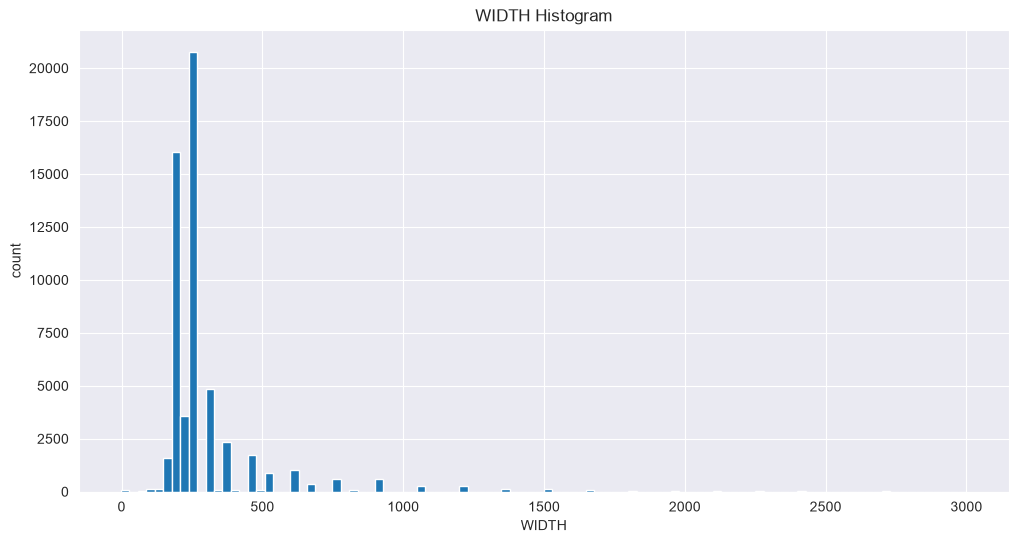

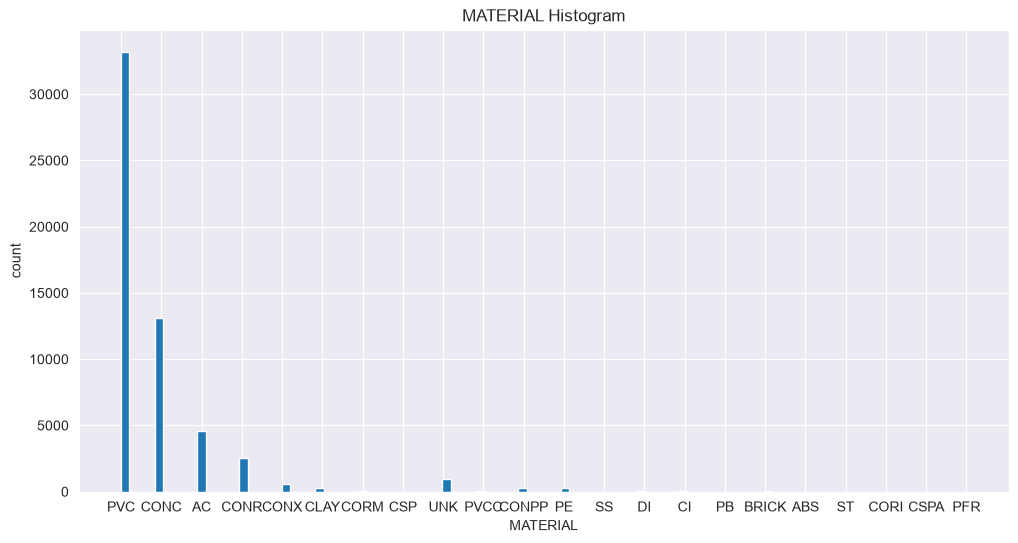

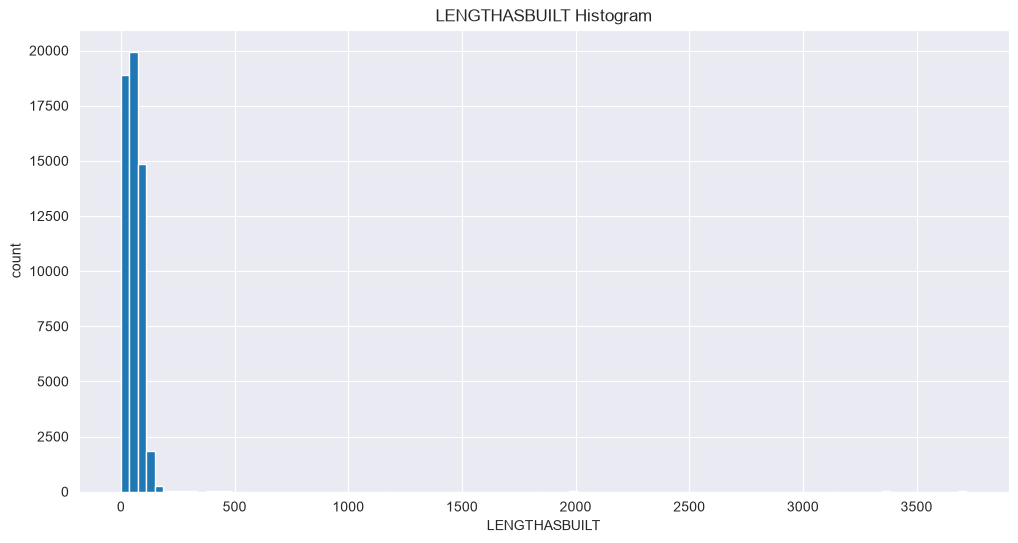

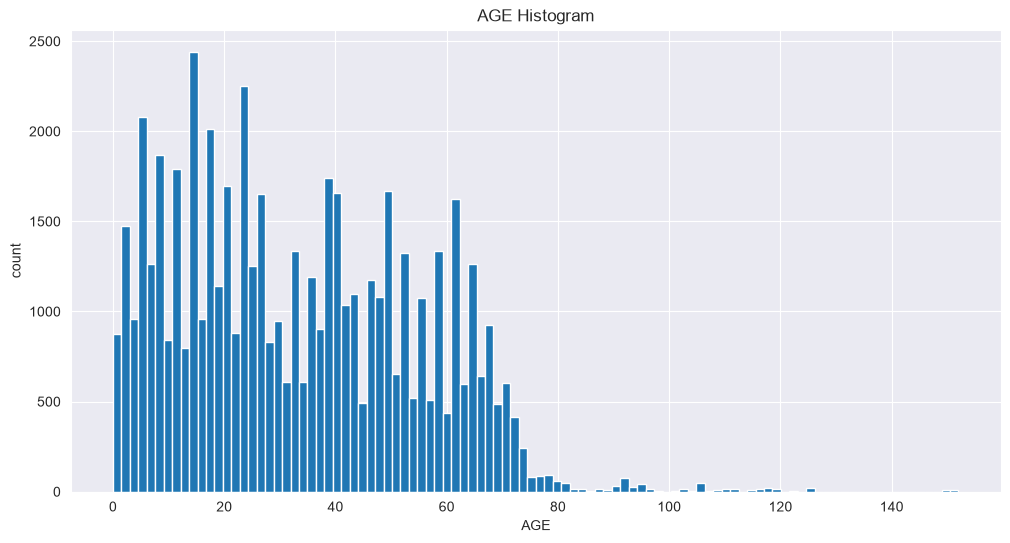

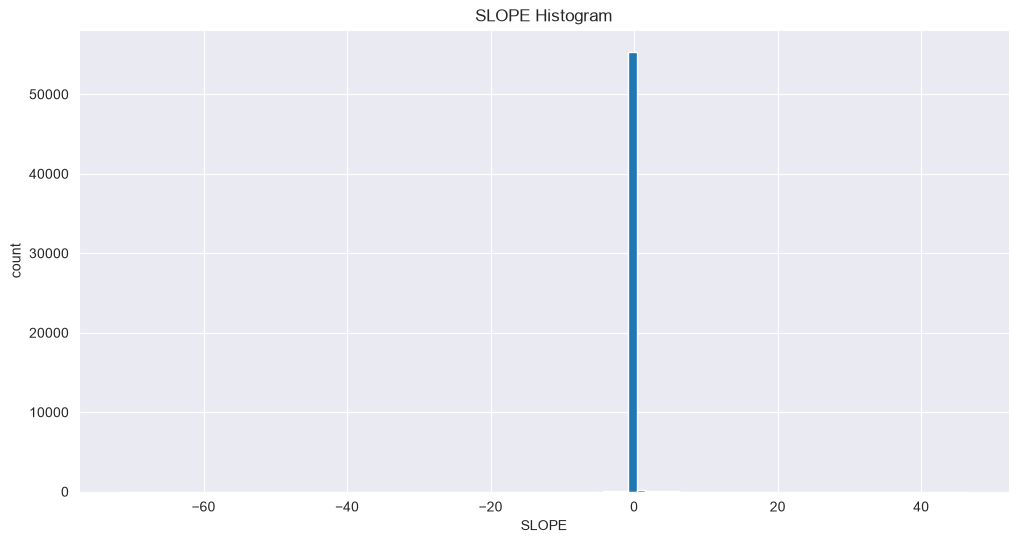

In [13]:
import matplotlib.pyplot as plt

features_for_hist = ["WIDTH", "MATERIAL", "LENGTHASBUILT", "AGE", "SLOPE"]

for feature in features_for_hist:
    plt.figure(figsize=(12, 6))
    plt.hist(pipes[feature], bins=100)
    plt.title(f"{feature} Histogram")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.show()

### 3.2 Visualizing Relationships between Features
- material vs age
- age vs length
- material vs length
- width vs material
- width vs age


#### 3.2.1 MATERIAL vs AGE

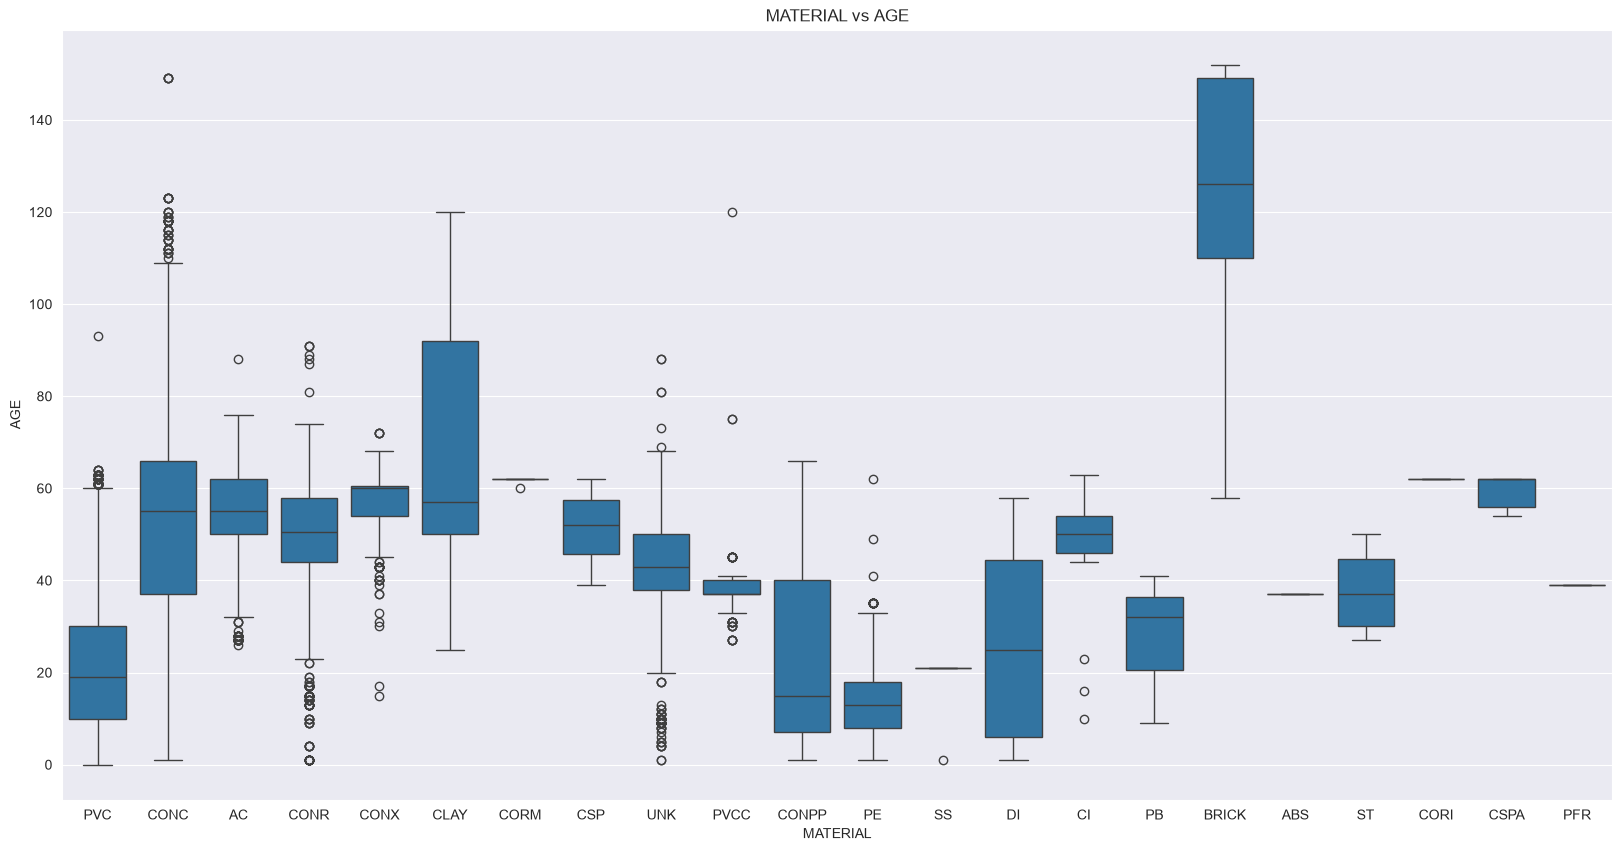

In [18]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x="MATERIAL", y="AGE", data=pipes[["MATERIAL", "AGE"]])
plt.title("MATERIAL vs AGE")
plt.show()

Looking at the graph above, material type exhibits a strong relationship with pipe age. PE appears to be the youngest, more modern material used. It has the lowest median (around 15 years) and has a relatively narrow interquartile range. This could suggest the recent increasing usage of the material in pipes. In contrast, brick pipes stand out as the oldest assets in the network, with a median age of approximately 130 years. This would make the pipes the oldest among the Ottawa pipes system, possibly making it more susceptible to deterioration, and requires more careful observation.

The analysis therefore shows that selection of material type differs across time periods. However, some of the old pipes are yet to be replaced. Modern materials such as PE and PVC are generally associated with newer installations, whereas materials such as brick, clay, and asbestos cement tend to be found in older sections of the network. Although age by itself does not equal to failure in the near-future, they can be weaker and more prone to damage, so it represents an important consideration in the development of the structural risk model.

#### 3.2.2 AGE vs LENGTH

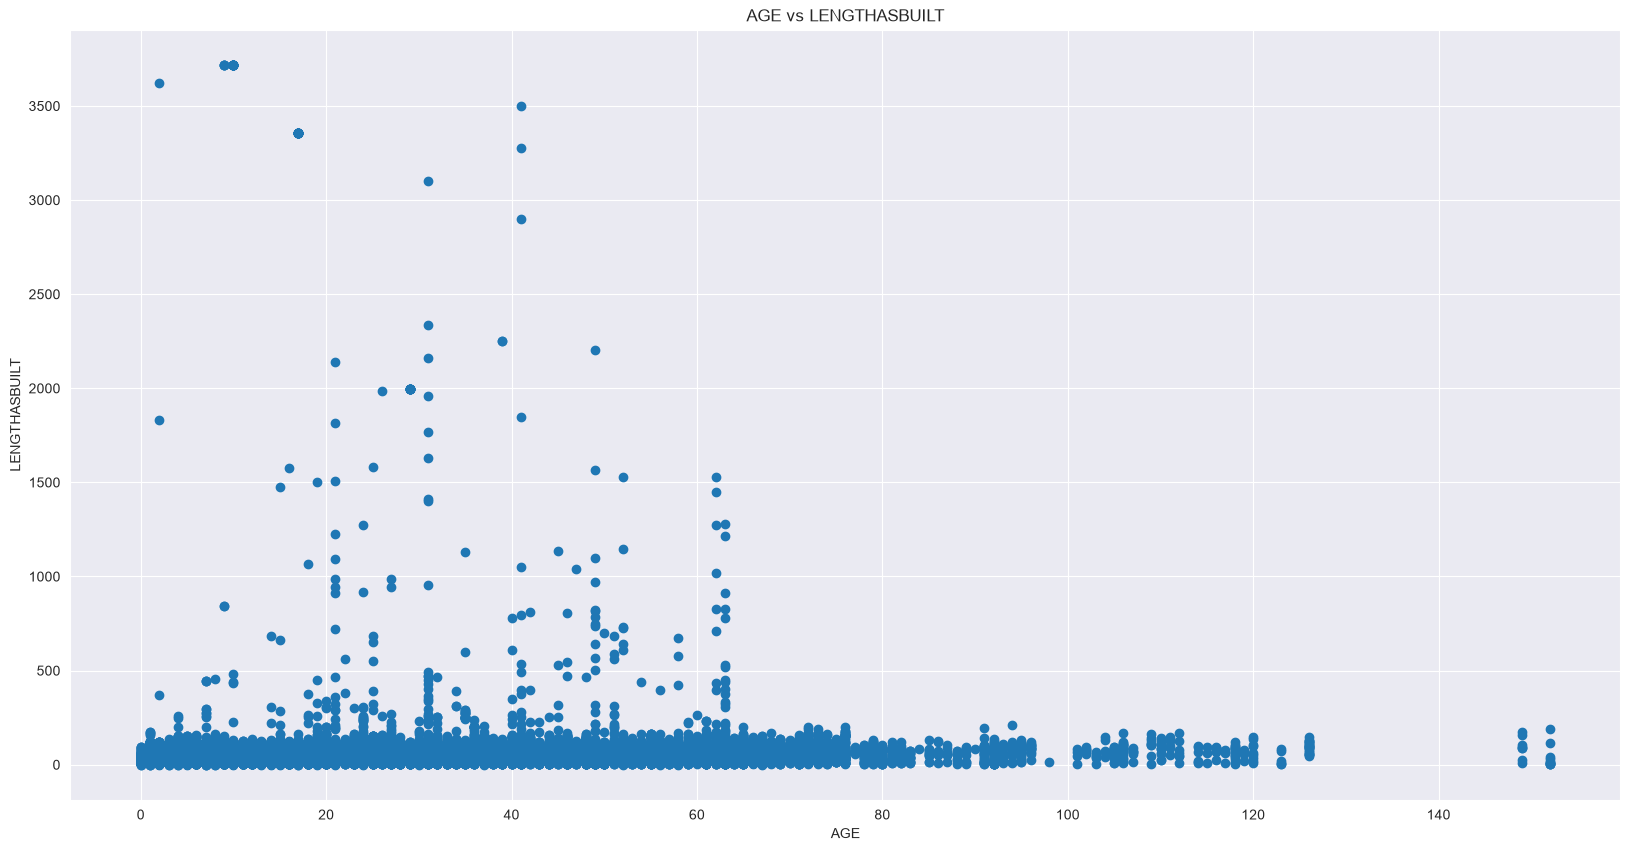

In [17]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes["AGE"], pipes["LENGTHASBUILT"])
plt.title("AGE vs LENGTHASBUILT")
plt.xlabel("AGE")
plt.ylabel("LENGTHASBUILT")
plt.show()

This figure shows the relationship between pipe age and pipe length. Overall, no strong correlation between age and length is immediately apparent, as short pipes are present across nearly all age groups. The majority of pipes, regardless of age, have lengths below approximately 250 units. However, the longest pipes in the network appear to be concentrated among younger and middle-aged assets (roughly 0~65 years old), while very old pipes tend to be shorter. This may suggest that more recent infrastructure projects included longer continuous pipe segments, supported with more modern technology and construction skills.

#### 3.2.3 MATERIAL vs LENGTH

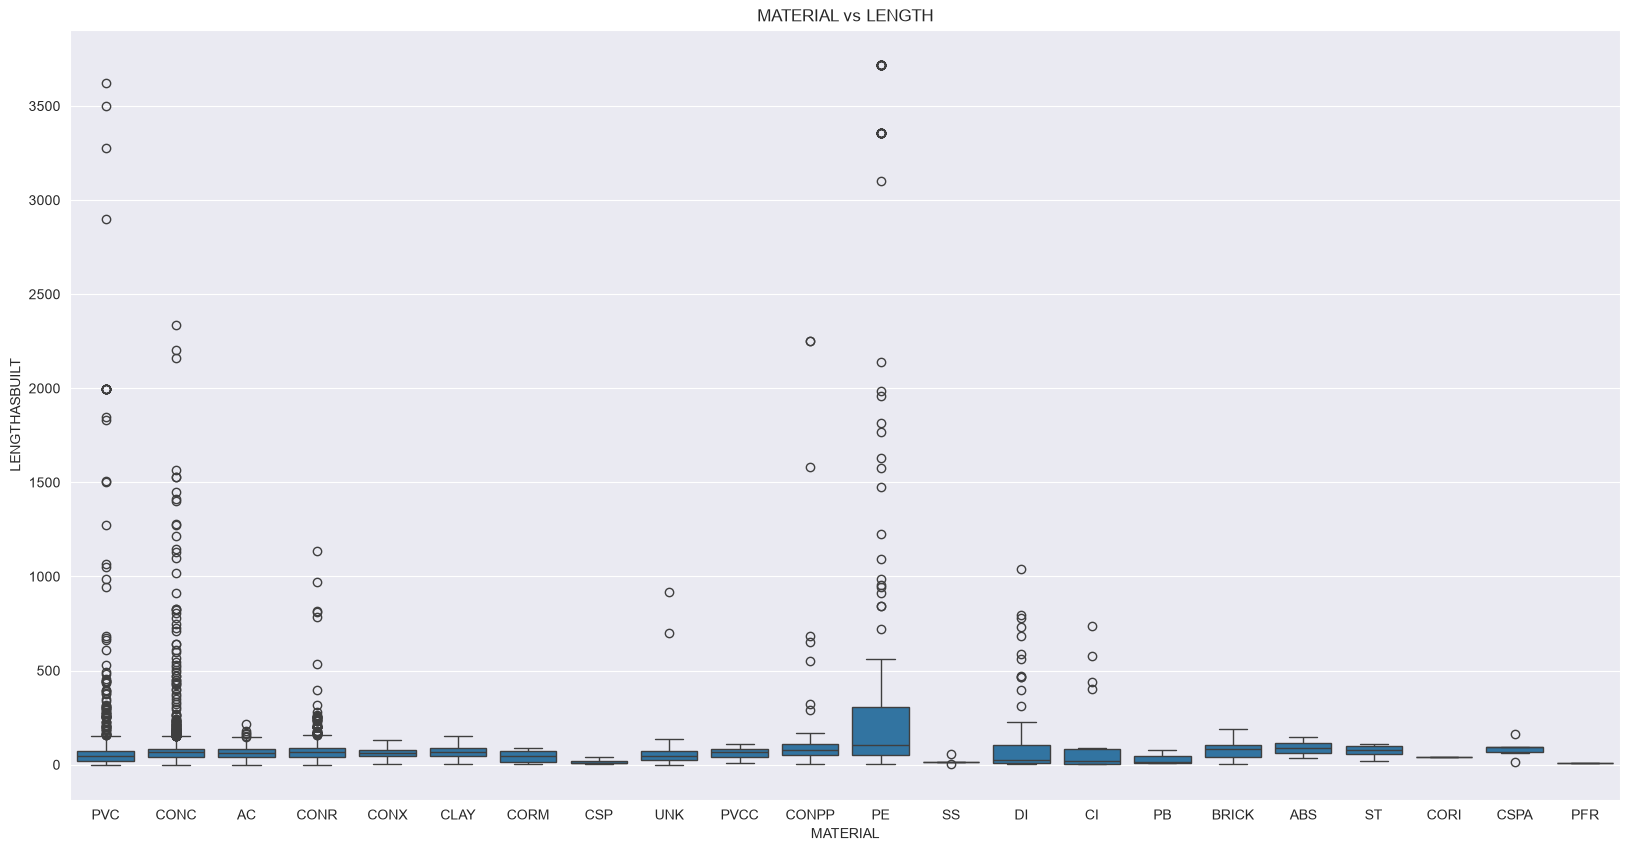

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="MATERIAL", y="LENGTHASBUILT", data=pipes[["MATERIAL", "LENGTHASBUILT"]])
plt.title("MATERIAL vs LENGTH")
plt.show()

The figure above illustrates the distribution of pipe lengths across material types. Most materials have median lengths below 100 units, showing that the majority of the sanitary system consist of relatively short pipes. However, notable differences exist between materials. PE pipes display one of the widest length distributions, indicating that they can be used in a variety of engineering contexts. Furthermore, PE is used for some of the longest pipes in Ottawa. PVC also contain many of the longest assets in the network while concrete-based materials are used in moderately long pipes. In contrast, brick pipes, being among one of the oldest material, show very short lengths. These results suggest that material choice may be associated not only with installation period but also with the engineering requirements of different sections of the sewer network.



## 4. Export Data

In [22]:
pipes.to_csv("data/pipes_data.csv", index=False, sep=",")